# Magnetic Shielding Calculation at Arbitrary Points — Pyrazine

This notebook computes the magnetic shielding tensor σ(r) at arbitrary points in space for the pyrazine molecule, using PySCF with the GIAO (Gauge-Including Atomic Orbitals) method.

**Computation workflow:**

1. Definition of the pyrazine geometry
1. SCF calculation (RHF or DFT)
1. Addition of ghost atoms (Bq) at points of interest NMR/GIAO calculation → shielding tensor σ
1. Interactive 3D visualization (molecule + points colored by NICS)

## 1. Imports

In [1]:
# Deactivate warnings
import warnings
warnings.filterwarnings('ignore')
from pyscf import gto, scf, dft
from pyscf.prop import nmr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go

# Conversion Å to Bohr
ANG2BOHR = 1.8897259886

print('PySCF version:', gto.__version__ if hasattr(gto, '__version__') else 'OK')
print('Imports OK')

PySCF version: OK
Imports OK


In [ ]:
# Load utility functions from GitHub
from urllib.request import urlopen

github_url = 'https://raw.githubusercontent.com/ycarissan/echem-yc/main/shielding_utils.py'
try:
    with urlopen(github_url) as response:
        exec(response.read().decode('utf-8'))
    print("✓ Utility functions loaded from GitHub")
except Exception as e:
    print(f"Could not load from GitHub: {e}")
    print("  Attempting to load from local file...")
    try:
        with open('shielding_utils.py', 'r') as f:
            exec(f.read())
        print("Utility functions loaded from local file")
    except Exception as e2:
        print(f"Error loading utility functions: {e2}")


✓ Utility functions loaded from GitHub


## 2. Pyrazine

Optimized geometry B3LYP/6-311+G(d,p), Angström.

In [3]:
# Pyrazine (C4H4N2)
PYRAZINE_ATOM = """
C    0.000000   1.394707   0.000000
C    0.000000  -1.394707   0.000000
N    1.147376   0.718445   0.000000
N   -1.147376   0.718445   0.000000
C    1.147376  -0.718445   0.000000
C   -1.147376  -0.718445   0.000000
H    0.000000   2.479737   0.000000
H    0.000000  -2.479737   0.000000
H    2.033173   1.242049   0.000000
H   -2.033173   1.242049   0.000000
H    2.033173  -1.242049   0.000000
H   -2.033173  -1.242049   0.000000
"""

# Parameters
BASIS = '6-311+G(d,p)'   # basis
GHOST_BASIS = [[0, [1e6, 1.0]]] # 1 s function, exponent 123
METHOD = 'RHF'           # 'RHF' or 'DFT-B3LYP'

print(f'Method : {METHOD}')
print(f'Basis : {BASIS}')
print(f'Ghost Basis : {GHOST_BASIS}')

Method : RHF
Basis : 6-311+G(d,p)
Ghost Basis : [[0, [1000000.0, 1.0]]]


## 3. Important points

Define directly or in a `.xyz` file.

In [4]:
# ─── Option A ───────────────────────────────────────────
points_ang = np.array([
    [0.5,  0.5,  0.5],   # 
    [0.0,  0.0,  0.0],   # 
    [0.0,  0.0,  1.0],   # 
    [0.0,  0.0, -1.0],   # 
    [0.0,  0.0,  2.0],   # 
    [1.0,  0.0,  0.0],   #
    [0.0,  1.0,  0.0],
], dtype=float)

# ─── Option B ─────────────────────────────────────
# Uncomment to read from a file (3 columns : x y z, in Angström)
# points_ang = np.loadtxt('points.xyz', comments='#')

print(f'{len(points_ang)} points loaded :')
for i, p in enumerate(points_ang):
    print(f'  [{i}]  x={p[0]:7.3f}  y={p[1]:7.3f}  z={p[2]:7.3f}  Å')



7 points loaded :
  [0]  x=  0.500  y=  0.500  z=  0.500  Å
  [1]  x=  0.000  y=  0.000  z=  0.000  Å
  [2]  x=  0.000  y=  0.000  z=  1.000  Å
  [3]  x=  0.000  y=  0.000  z= -1.000  Å
  [4]  x=  0.000  y=  0.000  z=  2.000  Å
  [5]  x=  1.000  y=  0.000  z=  0.000  Å
  [6]  x=  0.000  y=  1.000  z=  0.000  Å


## 4. Molecule with ghost atoms

In [5]:
mol = build_molecule_with_ghosts(PYRAZINE_ATOM, points_ang, BASIS, GHOST_BASIS)

n_real = len([l for l in PYRAZINE_ATOM.strip().split('\n') if l.strip()])
n_ghost = len(points_ang)
print(f'\nMolécule construite : {n_real} atomes réels + {n_ghost} atomes ghost')
print(f'Nombre total de fonctions de base : {mol.nao}')


Molécule construite : 12 atomes réels + 7 atomes ghost
Nombre total de fonctions de base : 175


## 5. SCF calculation

In [6]:
if METHOD == 'RHF':
    mf = scf.RHF(mol)
elif METHOD == 'DFT-B3LYP':
    mf = dft.RKS(mol)
    mf.xc = 'b3lyp'
else:
    raise ValueError(f'Méthode inconnue : {METHOD}')

mf.max_cycle = 200
mf.conv_tol = 1e-10

print(f'Running {METHOD}...')
energy = mf.kernel()
print(f'\nSCF Energie : {energy:.10f} Hartree')
print(f'Converged : {mf.converged}')

Running RHF...
converged SCF energy = -263.775568127379

SCF Energie : -263.7755681274 Hartree
Converged : True


## 6. Magnetic shielding

In [7]:
print('GIAO calculation...')

if METHOD == 'RHF':
    from pyscf.prop.nmr import rhf as nmr_mod
    mf_nmr = nmr_mod.NMR(mf)
elif METHOD == 'DFT-B3LYP':
    from pyscf.prop.nmr import rks as nmr_mod
    mf_nmr = nmr_mod.NMR(mf)

# Calcul de tous les tenseurs (atomes réels + ghosts)
shielding_all = mf_nmr.kernel()

print(f'\nCalcul done. Tensors computed for {len(shielding_all)} centres.')

GIAO calculation...

total shielding of atom 0 C
B_x [ 1.17045966e+01 -2.69299598e-08  2.41433752e-08]
B_y [-1.21055793e-07 -6.32079079e+01  4.35451253e-08]
B_z [-4.05124652e-07  3.18143503e-07  6.39065818e+01]
dia-magnetic contribution
B_x [ 2.68383885e+02  6.52595141e-08 -3.29661159e-10]
B_y [ 2.16737859e-09  2.56610909e+02 -1.86144758e-08]
B_z [1.94685725e-08 2.62251249e-08 2.34069822e+02]
para-magnetic contribution
B_x [-2.56679289e+02 -9.21894738e-08  2.44730364e-08]
B_y [-1.23223172e-07 -3.19818817e+02  6.21596011e-08]
B_z [-4.24593225e-07  2.91918378e-07 -1.70163240e+02]

total shielding of atom 1 C
B_x [ 7.64455506e+01 -8.01560992e-08  4.92636878e-08]
B_y [-8.49776351e-08 -8.52163182e+01 -2.20516963e-08]
B_z [-5.28971059e-08 -1.74553314e-07  1.06287221e+02]
dia-magnetic contribution
B_x [ 2.65863245e+02 -1.97464932e-08 -1.61826619e-09]
B_y [-1.48079365e-08  2.36086293e+02 -2.05806481e-09]
B_z [-9.52478987e-09  1.46600969e-08  2.20629279e+02]
para-magnetic contribution
B_x [-1.8

## 7. Extraction and analysis

In [8]:
# ─── Résultats sur les atomes ghost ───────────────────────────────────────────
results = []
print('=' * 75)
print(f'{"Point":>4}  {"x":>7} {"y":>7} {"z":>7}  {"σ_iso":>10}  {"NICS":>10}  {"NICS_zz":>10}')
print('=' * 75)

for i, point in enumerate(points_ang):
    idx = n_real + i  # indice dans le tableau de blindage
    sigma = shielding_all[idx]
    res = analyze_shielding(sigma)
    res['x'], res['y'], res['z'] = point
    res['point_idx'] = i
    results.append(res)
    
    print(f'[{i:2d}]  {point[0]:7.3f} {point[1]:7.3f} {point[2]:7.3f}  '
          f'{res["sigma_iso"]:10.3f}  {res["NICS"]:10.3f}  {res["NICS_zz"]:10.3f}')

print('=' * 75)
print('Toutes les valeurs en ppm.')

# ─── Résultats sur les noyaux réels ───────────────────────────────────────────
print('\n--- Blindage sur les noyaux réels ---')
atom_symbols = [mol.atom_symbol(i) for i in range(n_real)]
for i in range(n_real):
    sigma = shielding_all[i]
    sigma_iso = np.trace(sigma) / 3.0
    print(f'  Atome {i:2d} ({atom_symbols[i]:2s}): σ_iso = {sigma_iso:8.3f} ppm')

Point        x       y       z       σ_iso        NICS     NICS_zz
[ 0]    0.500   0.500   0.500     -68.218      68.218     238.587
[ 1]    0.000   0.000   0.000     -79.925      79.925     259.904
[ 2]    0.000   0.000   1.000     -62.133      62.133     180.897
[ 3]    0.000   0.000  -1.000     -62.133      62.133     180.897
[ 4]    0.000   0.000   2.000     -24.775      24.775      67.944
[ 5]    1.000   0.000   0.000     -16.393      16.393     134.680
[ 6]    0.000   1.000   0.000     -77.606      77.606     188.595
Toutes les valeurs en ppm.

--- Blindage sur les noyaux réels ---
  Atome  0 (C ): σ_iso =    4.134 ppm
  Atome  1 (C ): σ_iso =   32.505 ppm
  Atome  2 (N ): σ_iso =  120.100 ppm
  Atome  3 (N ): σ_iso =  120.100 ppm
  Atome  4 (C ): σ_iso =  121.079 ppm
  Atome  5 (C ): σ_iso =  121.079 ppm
  Atome  6 (H ): σ_iso =   30.415 ppm
  Atome  7 (H ): σ_iso =   30.255 ppm
  Atome  8 (H ): σ_iso =   33.600 ppm
  Atome  9 (H ): σ_iso =   33.600 ppm
  Atome 10 (H ): σ_iso = 

## 8. Tableau récapitulatif

In [9]:
df = pd.DataFrame([
    {
        'Point': f"[{r['point_idx']}]",
        'x (Å)': r['x'],
        'y (Å)': r['y'],
        'z (Å)': r['z'],
        'σ_iso (ppm)': round(r['sigma_iso'], 3),
        'σ_xx (ppm)':  round(r['sigma_xx'], 3),
        'σ_yy (ppm)':  round(r['sigma_yy'], 3),
        'σ_zz (ppm)':  round(r['sigma_zz'], 3),
        'NICS (ppm)':    round(r['NICS'], 3),
        'NICS_zz (ppm)': round(r['NICS_zz'], 3),
    }
    for r in results
])

# Mise en forme avec gradient de couleur sur NICS
df.style.background_gradient(
    subset=['NICS (ppm)', 'NICS_zz (ppm)'],
    cmap='RdBu_r',
    vmin=-20, vmax=20
).format(precision=3)

,Point,x (Å),y (Å),z (Å),σ_iso (ppm),σ_xx (ppm),σ_yy (ppm),σ_zz (ppm),NICS (ppm),NICS_zz (ppm)
0,[0],0.500,0.500,0.500,-68.218,18.090,15.844,-238.587,68.218,238.587
1,[1],0.000,0.000,0.000,-79.925,17.571,2.559,-259.904,79.925,259.904
2,[2],0.000,0.000,1.000,-62.133,-0.421,-5.081,-180.897,62.133,180.897
3,[3],0.000,0.000,-1.000,-62.133,-0.421,-5.081,-180.897,62.133,180.897
4,[4],0.000,0.000,2.000,-24.775,-2.828,-3.552,-67.944,24.775,67.944
5,[5],1.000,0.000,0.000,-16.393,50.274,35.226,-134.680,16.393,134.680
6,[6],0.000,1.000,0.000,-77.606,25.681,-69.904,-188.595,77.606,188.595


## 9. Visualisation 3D interactive

La molécule est affichée en fil de fer (stick model) et les points de calcul sont représentés par des sphères colorées selon la valeur du NICS.

**Convention de couleur :**
- 🔵 Bleu → NICS négatif → **blindage, zone aromatique (courants de cycle diamagnétiques)**
- ⚪ Blanc → NICS ≈ 0 → zone neutre
- 🔴 Rouge → NICS positif → **déblindage, zone antiaromatique ou en dehors**

In [10]:
# Couleurs CPK classiques pour les atomes
CPK_COLORS = {
    'C': '#404040', 'N': '#3050F8', 'O': '#FF0D0D',
    'H': '#CCCCCC', 'S': '#FFFF30', 'F': '#90E050',
    'Cl': '#1FF01F', 'default': '#FF69B4'
}
ATOM_RADIUS = {'C': 0.15, 'N': 0.14, 'O': 0.13, 'H': 0.08, 'default': 0.15}

atoms_mol = get_molecule_coords(PYRAZINE_ATOM)
bonds = get_bond_pairs(atoms_mol)

# ─── Normalisation des NICS pour la colormap ─────────────────────────────────
nics_values = np.array([r['NICS'] for r in results])
vmax = max(abs(nics_values).max(), 1.0)  # symétrie autour de 0
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.colormaps['RdBu_r']

def nics_to_hex(nics_val):
    rgba = cmap(norm(nics_val))
    return mcolors.to_hex(rgba)


# ─── Construction de la figure Plotly ────────────────────────────────────────
fig = go.Figure()

# -- Liaisons (tubes)
for i, j in bonds:
    a, b = atoms_mol[i], atoms_mol[j]
    fig.add_trace(go.Scatter3d(
        x=[a['x'], b['x']], y=[a['y'], b['y']], z=[a['z'], b['z']],
        mode='lines',
        line=dict(color='#888888', width=8),
        showlegend=False,
        hoverinfo='skip'
    ))

# -- Atomes
for atom in atoms_mol:
    sym = atom['symbol']
    color = CPK_COLORS.get(sym, CPK_COLORS['default'])
    size = ATOM_RADIUS.get(sym, ATOM_RADIUS['default']) * 200
    fig.add_trace(go.Scatter3d(
        x=[atom['x']], y=[atom['y']], z=[atom['z']],
        mode='markers',
        marker=dict(size=size/10, color=color, opacity=1.0,
                    line=dict(color='black', width=1)),
        name=sym,
        showlegend=False,
        hovertemplate=f'<b>{sym}</b><br>x={atom["x"]:.3f}<br>y={atom["y"]:.3f}<br>z={atom["z"]:.3f}<extra></extra>'
    ))

# -- Points de calcul (sphères colorées par NICS)
point_colors = [nics_to_hex(r['NICS']) for r in results]
hover_texts = [
    f'<b>Point [{r["point_idx"]}]</b><br>'
    f'x={r["x"]:.3f} Å<br>y={r["y"]:.3f} Å<br>z={r["z"]:.3f} Å<br>'
    f'<b>σ_iso = {r["sigma_iso"]:.2f} ppm</b><br>'
    f'<b>NICS = {r["NICS"]:.2f} ppm</b><br>'
    f'NICS_zz = {r["NICS_zz"]:.2f} ppm'
    for r in results
]

fig.add_trace(go.Scatter3d(
    x=[r['x'] for r in results],
    y=[r['y'] for r in results],
    z=[r['z'] for r in results],
    mode='markers+text',
    marker=dict(
        size=14,
        color=[r['NICS'] for r in results],
        colorscale='RdBu_r',
        cmin=-vmax, cmax=vmax,
        colorbar=dict(
            title=dict(text='NICS (ppm)', side='right'),
            thickness=20, len=0.6,
            tickformat='.1f'
        ),
        opacity=0.90,
        symbol='circle',
        line=dict(color='black', width=1)
    ),
    text=[f'[{r["point_idx"]}]' for r in results],
    textfont=dict(size=10, color='black'),
    textposition='top center',
    hovertemplate='%{customdata}<extra></extra>',
    customdata=hover_texts,
    name='Points de calcul'
))

# -- Mise en page
fig.update_layout(
    title=dict(
        text='Blindage magnétique — Pyrazine<br>'
             '<sup>Sphères colorées par NICS (ppm) | Bleu = blindé (aromatique) | Rouge = déblindé</sup>',
        x=0.5, font=dict(size=16)
    ),
    scene=dict(
        xaxis=dict(title='x (Å)', showgrid=True, gridcolor='lightgray'),
        yaxis=dict(title='y (Å)', showgrid=True, gridcolor='lightgray'),
        zaxis=dict(title='z (Å)', showgrid=True, gridcolor='lightgray'),
        bgcolor='white',
        aspectmode='data',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    width=850, height=680,
    margin=dict(l=0, r=0, b=0, t=80),
    legend=dict(x=0.01, y=0.99)
)

fig.show()
print('\n💡 La figure est interactive : rotation, zoom, survol des points pour voir les valeurs.')


💡 La figure est interactive : rotation, zoom, survol des points pour voir les valeurs.


## 10. Visualisation complémentaire : tenseurs complets

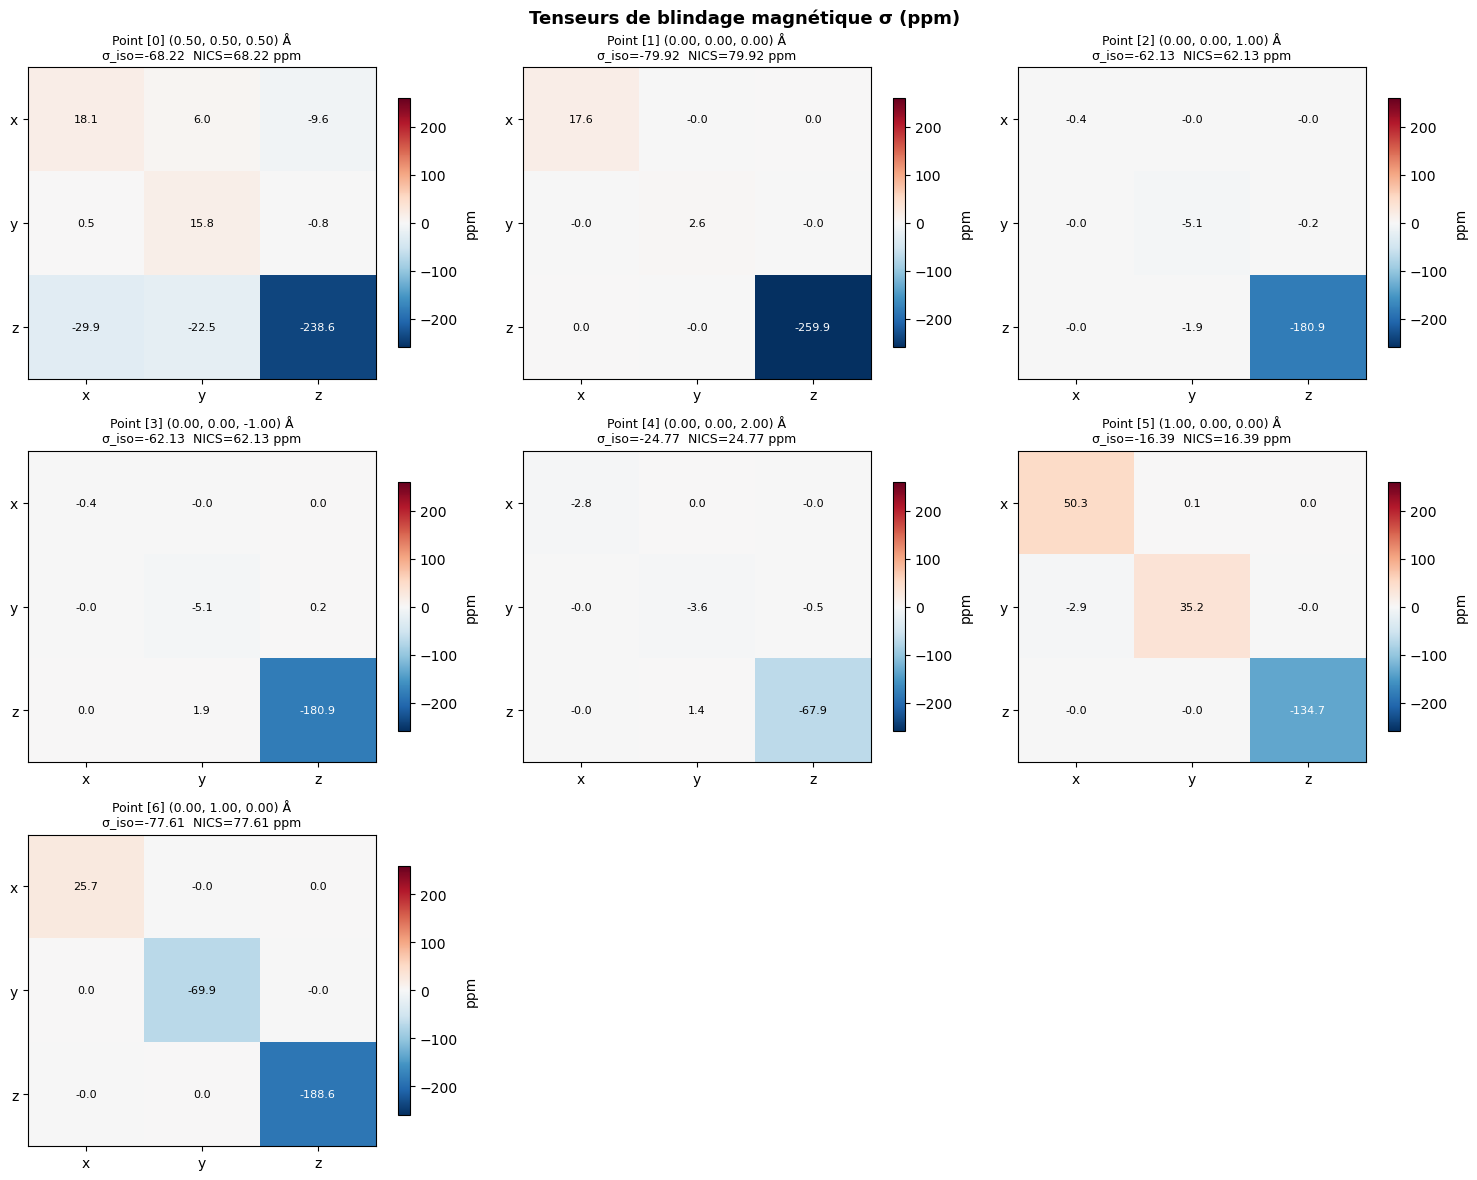

Figure sauvegardée : tenseurs_blindage.png


In [11]:
n_pts = len(results)
ncols = min(3, n_pts)
nrows = (n_pts + ncols - 1) // ncols

fig2, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).flatten() if n_pts > 1 else [axes]

vmax_tensor = max(abs(r['tensor']).max() for r in results)

for i, r in enumerate(results):
    ax = axes[i]
    im = ax.imshow(r['tensor'], cmap='RdBu_r',
                   vmin=-vmax_tensor, vmax=vmax_tensor, aspect='auto')
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['x', 'y', 'z'])
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['x', 'y', 'z'])
    ax.set_title(f"Point [{i}] ({r['x']:.2f}, {r['y']:.2f}, {r['z']:.2f}) Å\n"
                 f"σ_iso={r['sigma_iso']:.2f}  NICS={r['NICS']:.2f} ppm",
                 fontsize=9)
    for ii in range(3):
        for jj in range(3):
            ax.text(jj, ii, f"{r['tensor'][ii, jj]:.1f}",
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(r['tensor'][ii, jj]) > vmax_tensor*0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8, label='ppm')

# Masquer les axes vides
for i in range(len(results), len(axes)):
    axes[i].set_visible(False)

fig2.suptitle('Tenseurs de blindage magnétique σ (ppm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tenseurs_blindage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : tenseurs_blindage.png')

## 11. Export des résultats

In [12]:
# Export CSV
df.to_csv('shielding_results.csv', index=False)
print('Résultats exportés dans : shielding_results.csv')

# Export des tenseurs complets (numpy)
tensors_array = np.array([r['tensor'] for r in results])  # shape (N, 3, 3)
np.save('shielding_tensors.npy', tensors_array)
print(f'Tenseurs exportés dans : shielding_tensors.npy  (shape = {tensors_array.shape})')

# Résumé final
print('\n' + '='*50)
print('RÉSUMÉ FINAL')
print('='*50)
for r in results:
    print(f"  Point [{r['point_idx']}] ({r['x']:.2f}, {r['y']:.2f}, {r['z']:.2f}) Å"
          f" → NICS = {r['NICS']:+.2f} ppm  |  NICS_zz = {r['NICS_zz']:+.2f} ppm")

Résultats exportés dans : shielding_results.csv
Tenseurs exportés dans : shielding_tensors.npy  (shape = (7, 3, 3))

RÉSUMÉ FINAL
  Point [0] (0.50, 0.50, 0.50) Å → NICS = +68.22 ppm  |  NICS_zz = +238.59 ppm
  Point [1] (0.00, 0.00, 0.00) Å → NICS = +79.92 ppm  |  NICS_zz = +259.90 ppm
  Point [2] (0.00, 0.00, 1.00) Å → NICS = +62.13 ppm  |  NICS_zz = +180.90 ppm
  Point [3] (0.00, 0.00, -1.00) Å → NICS = +62.13 ppm  |  NICS_zz = +180.90 ppm
  Point [4] (0.00, 0.00, 2.00) Å → NICS = +24.77 ppm  |  NICS_zz = +67.94 ppm
  Point [5] (1.00, 0.00, 0.00) Å → NICS = +16.39 ppm  |  NICS_zz = +134.68 ppm
  Point [6] (0.00, 1.00, 0.00) Å → NICS = +77.61 ppm  |  NICS_zz = +188.60 ppm


## 12. Utilisation avec un fichier de points externe

Pour utiliser ce notebook avec votre propre liste de points, créez un fichier texte `points.xyz` avec le format suivant :

```
# x       y       z       (en Angström, commentaires commençant par #)
  0.5     0.5     0.5
  0.0     0.0     0.0
  0.0     0.0     1.0
  ...
```

Puis dans la cellule 3, remplacez la définition manuelle par :

```python
points_ang = np.loadtxt('points.xyz', comments='#')
```

Le reste du notebook fonctionne sans modification.

---

## Références

- **NICS** : Schleyer et al., *J. Am. Chem. Soc.* **1996**, 118, 6317.
- **GIAO** : Wolinski et al., *J. Am. Chem. Soc.* **1990**, 112, 8251.
- **PySCF** : Sun et al., *WIREs Comput. Mol. Sci.* **2018**, 8, e1340.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

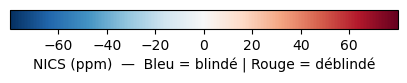

In [13]:
nics_values = np.array([r['NICS'] for r in results])
visualize_molecule_with_points(atoms_mol, bonds, results, nics_values)